# Intel Image Classification with ResNet50

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import kagglehub
import os
import shutil

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    if hasattr(torch, "set_float32_matmul_precision"):
        torch.set_float32_matmul_precision("high")

print(f"Using device: {device}")

Using device: cuda


## Dataset Preparation

In [24]:
print("Preparing dataset...")

local_dataset_dir = os.path.join(os.getcwd(), "intel-image-classification")

if not os.path.exists(local_dataset_dir):
    print("Downloading dataset to kagglehub cache...")
    cached_path = kagglehub.dataset_download("puneet6060/intel-image-classification")
    print("Cached dataset path:", cached_path)
    print("Copying dataset to local notebook folder...")
    shutil.copytree(cached_path, local_dataset_dir)
else:
    print("Local dataset already exists:", local_dataset_dir)

print("Using dataset path:", local_dataset_dir)

train_dir = os.path.join(local_dataset_dir, "seg_train", "seg_train")
test_dir = os.path.join(local_dataset_dir, "seg_test", "seg_test")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

trainset = torchvision.datasets.ImageFolder(root=train_dir, transform=transform)
testset = torchvision.datasets.ImageFolder(root=test_dir, transform=transform)

batch_size = 32
num_workers = min(8, os.cpu_count() or 1)
use_cuda = device.type == "cuda"

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=use_cuda,
    persistent_workers=(num_workers > 0),
    prefetch_factor=4 if num_workers > 0 else None
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=use_cuda,
    persistent_workers=(num_workers > 0),
    prefetch_factor=4 if num_workers > 0 else None
)

num_classes = len(trainset.classes)
print(f"Classes found: {trainset.classes}")
print(f"Batch size: {batch_size}, DataLoader workers: {num_workers}")

Preparing dataset...
Local dataset already exists: c:\Users\belw2\Desktop\ALL\ML && DL\check_point_18\intel-image-classification
Using dataset path: c:\Users\belw2\Desktop\ALL\ML && DL\check_point_18\intel-image-classification
Classes found: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Batch size: 32, DataLoader workers: 8


## Model Setup

In [ ]:
model = torchvision.models.resnet50(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

model = model.to(device)

## Feature Extraction Training

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

epochs = 15
print_every = 50
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

print("--- Starting Feature Extraction ---")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for step, (images, labels) in enumerate(trainloader, start=1):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        if step % print_every == 0 or step == len(trainloader):
            avg_train_loss = running_loss / step
            print(
                f"Epoch [{epoch+1}/{epochs}] Step [{step}/{len(trainloader)}] Train Avg Loss: {avg_train_loss:.4f}",
                flush=True
            )

    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type=device.type, enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    print(
        f"Epoch {epoch+1}/{epochs} - Train Loss: {running_loss/len(trainloader):.4f} - Val Loss: {val_loss/len(testloader):.4f} - Val Accuracy: {val_accuracy:.2f}%",
        flush=True
    )

--- Starting Feature Extraction ---
Epoch [1/15] Step [50/439] Train Avg Loss: 0.9978
Epoch [1/15] Step [100/439] Train Avg Loss: 0.7339
Epoch [1/15] Step [150/439] Train Avg Loss: 0.6380
Epoch [1/15] Step [200/439] Train Avg Loss: 0.5826
Epoch [1/15] Step [250/439] Train Avg Loss: 0.5419
Epoch [1/15] Step [300/439] Train Avg Loss: 0.5227
Epoch [1/15] Step [350/439] Train Avg Loss: 0.5045
Epoch [1/15] Step [400/439] Train Avg Loss: 0.4896
Epoch [1/15] Step [439/439] Train Avg Loss: 0.4814
Epoch 1/15 - Train Loss: 0.4814 - Val Loss: 0.2682 - Val Accuracy: 90.00%
Epoch [2/15] Step [50/439] Train Avg Loss: 0.3704
Epoch [2/15] Step [100/439] Train Avg Loss: 0.3684
Epoch [2/15] Step [150/439] Train Avg Loss: 0.3688
Epoch [2/15] Step [200/439] Train Avg Loss: 0.3587
Epoch [2/15] Step [250/439] Train Avg Loss: 0.3521
Epoch [2/15] Step [300/439] Train Avg Loss: 0.3501
Epoch [2/15] Step [350/439] Train Avg Loss: 0.3473
Epoch [2/15] Step [400/439] Train Avg Loss: 0.3464
Epoch [2/15] Step [439/43

## Fine-Tuning

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)

epochs = 15
print_every = 50
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

print("--- Starting Fine-Tuning (layer4 + fc) ---")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for step, (images, labels) in enumerate(trainloader, start=1):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        if step % print_every == 0 or step == len(trainloader):
            avg_train_loss = running_loss / step
            print(
                f"Fine-tune Epoch [{epoch+1}/{epochs}] Step [{step}/{len(trainloader)}] Train Avg Loss: {avg_train_loss:.4f}",
                flush=True
            )

    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type=device.type, enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    print(
        f"Fine-tune Epoch {epoch+1}/{epochs} - Train Loss: {running_loss/len(trainloader):.4f} - Val Loss: {val_loss/len(testloader):.4f} - Val Accuracy: {val_accuracy:.2f}%",
        flush=True
    )

--- Starting Fine-Tuning (layer4 + fc) ---
Fine-tune Epoch [1/15] Step [50/439] Train Avg Loss: 0.2292
Fine-tune Epoch [1/15] Step [100/439] Train Avg Loss: 0.2425
Fine-tune Epoch [1/15] Step [150/439] Train Avg Loss: 0.2375
Fine-tune Epoch [1/15] Step [200/439] Train Avg Loss: 0.2331
Fine-tune Epoch [1/15] Step [250/439] Train Avg Loss: 0.2324
Fine-tune Epoch [1/15] Step [300/439] Train Avg Loss: 0.2340
Fine-tune Epoch [1/15] Step [350/439] Train Avg Loss: 0.2312
Fine-tune Epoch [1/15] Step [400/439] Train Avg Loss: 0.2310
Fine-tune Epoch [1/15] Step [439/439] Train Avg Loss: 0.2316
Fine-tune Epoch 1/15 - Train Loss: 0.2316 - Val Loss: 0.1966 - Val Accuracy: 92.77%
Fine-tune Epoch [2/15] Step [50/439] Train Avg Loss: 0.1999
Fine-tune Epoch [2/15] Step [100/439] Train Avg Loss: 0.1816
Fine-tune Epoch [2/15] Step [150/439] Train Avg Loss: 0.1757
Fine-tune Epoch [2/15] Step [200/439] Train Avg Loss: 0.1738
Fine-tune Epoch [2/15] Step [250/439] Train Avg Loss: 0.1748
Fine-tune Epoch [2/15

## Prediction on seg_pred


In [29]:
from PIL import Image
import csv

candidate_pred_dirs = [
    os.path.join(local_dataset_dir, "seg_pred", "seg_pred"),
    os.path.join(local_dataset_dir, "seg_pred")
]

pred_dir = next((d for d in candidate_pred_dirs if os.path.isdir(d)), None)
if pred_dir is None:
    raise FileNotFoundError(
        f"Could not find seg_pred folder. Checked: {candidate_pred_dirs}"
    )

image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
pred_files = sorted([
    f for f in os.listdir(pred_dir)
    if f.lower().endswith(image_exts) and os.path.isfile(os.path.join(pred_dir, f))
])

if len(pred_files) == 0:
    raise ValueError(f"No images found in {pred_dir}")

print(f"Prediction folder: {pred_dir}", flush=True)
print(f"Total images to predict: {len(pred_files)}", flush=True)

model.eval()
use_amp_pred = device.type == "cuda"
pred_rows = []
progress_every = 100

with torch.no_grad():
    for i, filename in enumerate(pred_files, start=1):
        img_path = os.path.join(pred_dir, filename)
        image = Image.open(img_path).convert("RGB")

        x = transform(image).unsqueeze(0).to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, enabled=use_amp_pred):
            logits = model(x)
        pred_idx = int(torch.argmax(logits, dim=1).item())
        pred_label = trainset.classes[pred_idx]

        pred_rows.append((filename, pred_idx, pred_label))

        if i % progress_every == 0 or i == len(pred_files):
            print(f"Processed {i}/{len(pred_files)} images...", flush=True)

output_csv = os.path.join(local_dataset_dir, "seg_pred_predictions.csv")
with open(output_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["image", "predicted_class_index", "predicted_class"])
    writer.writerows(pred_rows)

print(f"Predicted {len(pred_rows)} images from: {pred_dir}", flush=True)
print(f"Saved predictions to: {output_csv}", flush=True)
print("Sample predictions:", flush=True)
for row in pred_rows[:10]:
    print(row)

Prediction folder: c:\Users\belw2\Desktop\ALL\ML && DL\check_point_18\intel-image-classification\seg_pred\seg_pred
Total images to predict: 7301
Processed 100/7301 images...
Processed 200/7301 images...
Processed 300/7301 images...
Processed 400/7301 images...
Processed 500/7301 images...
Processed 600/7301 images...
Processed 700/7301 images...
Processed 800/7301 images...
Processed 900/7301 images...
Processed 1000/7301 images...
Processed 1100/7301 images...
Processed 1200/7301 images...
Processed 1300/7301 images...
Processed 1400/7301 images...
Processed 1500/7301 images...
Processed 1600/7301 images...
Processed 1700/7301 images...
Processed 1800/7301 images...
Processed 1900/7301 images...
Processed 2000/7301 images...
Processed 2100/7301 images...
Processed 2200/7301 images...
Processed 2300/7301 images...
Processed 2400/7301 images...
Processed 2500/7301 images...
Processed 2600/7301 images...
Processed 2700/7301 images...
Processed 2800/7301 images...
Processed 2900/7301 imag

## Sample Prediction Visuals
Display random predicted images from seg_pred with their predicted labels.

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000002A4DB9F4AE0>
Traceback (most recent call last):
  File "c:\Users\belw2\Desktop\ALL\ML && DL\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "c:\Users\belw2\Desktop\ALL\ML && DL\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1666, in _shutdown_workers
    self._mark_worker_as_unavailable(worker_id, shutdown=True)
  File "c:\Users\belw2\Desktop\ALL\ML && DL\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1595, in _mark_worker_as_unavailable
    not self._workers_status[worker_id]
        ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


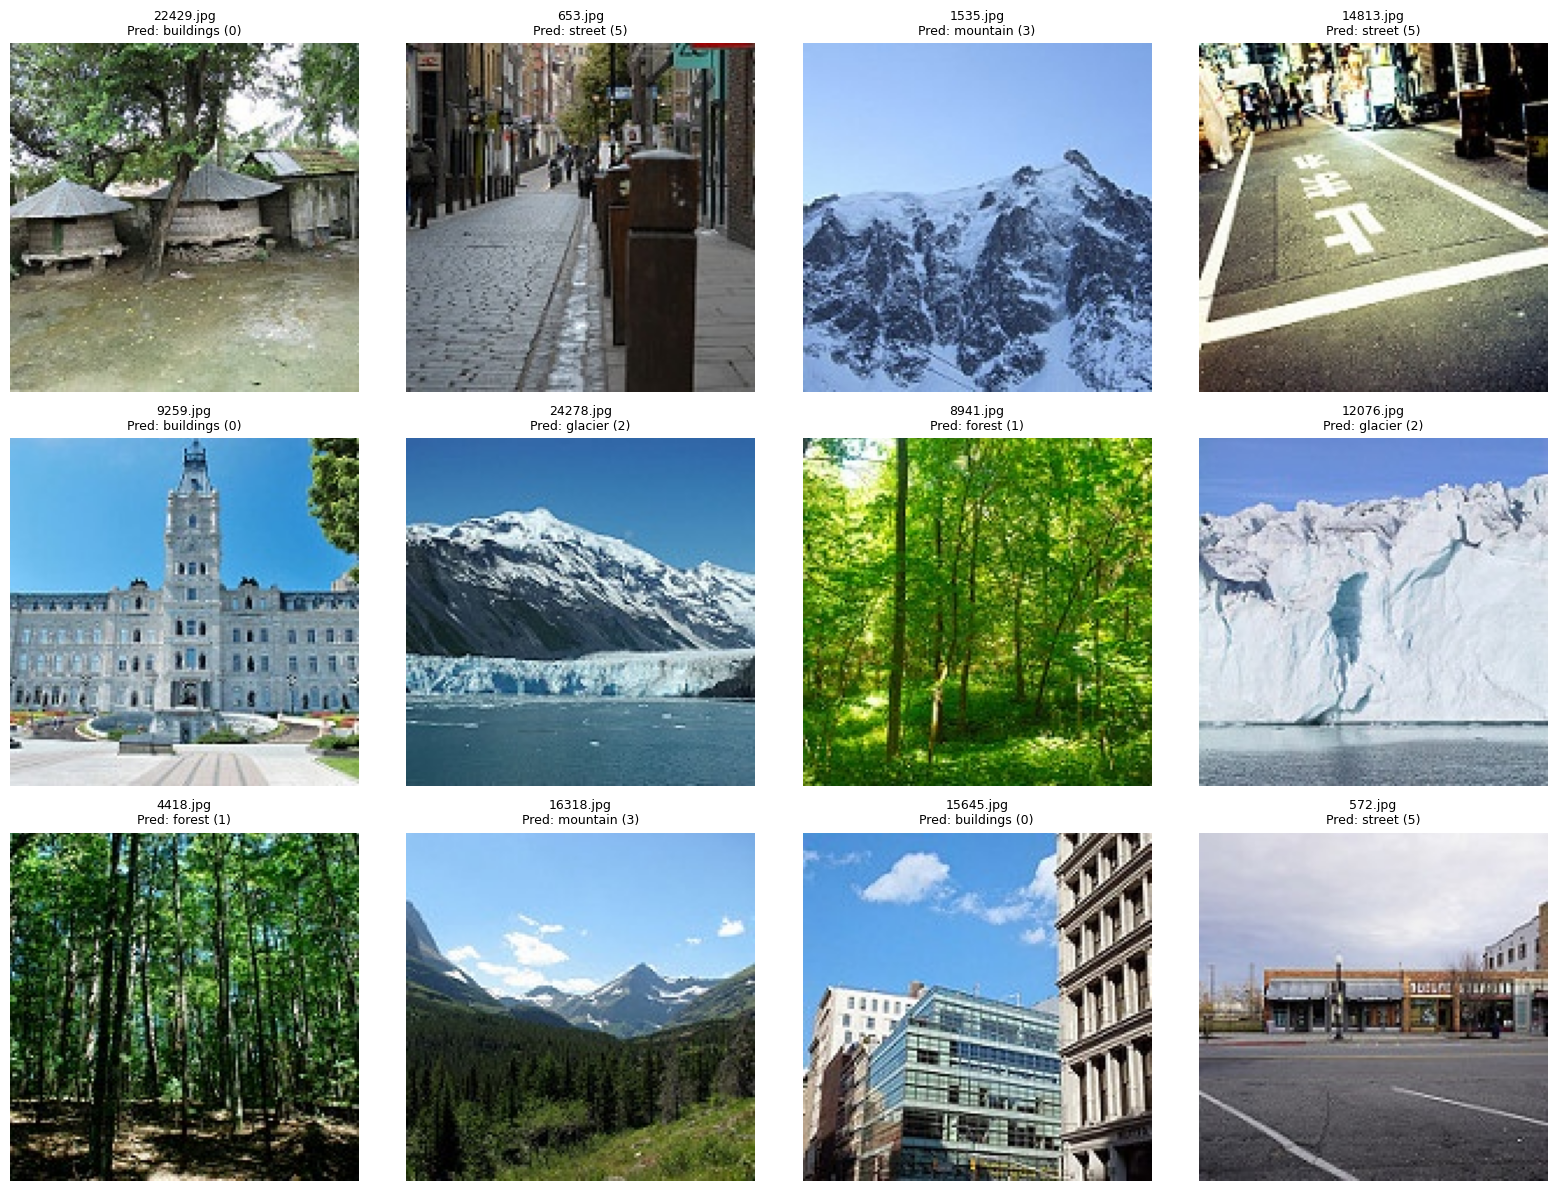

Displayed 12 sample predictions from seg_pred


In [30]:
import matplotlib.pyplot as plt
import random

sample_count = 12

if 'pred_rows' not in globals() or len(pred_rows) == 0:
    output_csv = os.path.join(local_dataset_dir, "seg_pred_predictions.csv")
    if not os.path.isfile(output_csv):
        raise FileNotFoundError(
            "No prediction data found. Run the prediction cell first to generate seg_pred_predictions.csv"
        )

    pred_rows = []
    with open(output_csv, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            pred_rows.append((row["image"], int(row["predicted_class_index"]), row["predicted_class"]))

if len(pred_rows) == 0:
    raise ValueError("No predictions available to display")

sample_n = min(sample_count, len(pred_rows))
sample_rows = random.sample(pred_rows, sample_n)

cols = 4
rows = (sample_n + cols - 1) // cols
plt.figure(figsize=(4 * cols, 4 * rows))

for i, (filename, pred_idx, pred_label) in enumerate(sample_rows, start=1):
    img_path = os.path.join(pred_dir, filename)
    img = Image.open(img_path).convert("RGB")

    ax = plt.subplot(rows, cols, i)
    ax.imshow(img)
    ax.set_title(f"{filename}\nPred: {pred_label} ({pred_idx})", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Displayed {sample_n} sample predictions from seg_pred")